In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("customer_churn.csv")
df.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [5]:
df.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [6]:
df.columns


Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'gender', 'region', 'churn'],
      dtype='object')

In [7]:
df.columns.value_counts()

age                      1
income                   1
credit_score             1
transactions_month       1
avg_purchase_value       1
days_since_last_login    1
tenure_months            1
num_products             1
gender                   1
region                   1
churn                    1
Name: count, dtype: int64

In [9]:
df['churn'].value_counts()

churn
1    517
0    483
Name: count, dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   object 
 9   region                 1000 non-null   object 
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 86.1+ KB


In [11]:
df.describe()


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


In [12]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:")
print(list(categorical_cols))

print("\nNumerical Columns:")
print(list(numerical_cols))


Categorical Columns:
['gender', 'region']

Numerical Columns:
['age', 'income', 'credit_score', 'transactions_month', 'avg_purchase_value', 'days_since_last_login', 'tenure_months', 'num_products', 'churn']


In [13]:
# data preprocessing
df.isnull().sum()


age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [14]:
mean_income=df['income'].mean()
median_income=df['income'].median()
mode_income=df['income'].mode()
print("mean:",mean_income)
print("median:",median_income)
print("mode:",mode_income)

mean: 55354.41751318089
median: 51298.8468120935
mode: 0    254852.478291
Name: income, dtype: float64


In [16]:
#check the outlier ratio in the income column
Q1 = df["income"].quantile(0.25)
Q3 = df["income"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["income"] < lower_bound) | (df["income"] > upper_bound)]

outlier_ratio = len(outliers) / len(df)

print("Number of outliers in income:", len(outliers))
print("Outlier ratio in income:", outlier_ratio)
print("Outlier percentage in income:", outlier_ratio * 100)

Number of outliers in income: 23
Outlier ratio in income: 0.023
Outlier percentage in income: 2.3


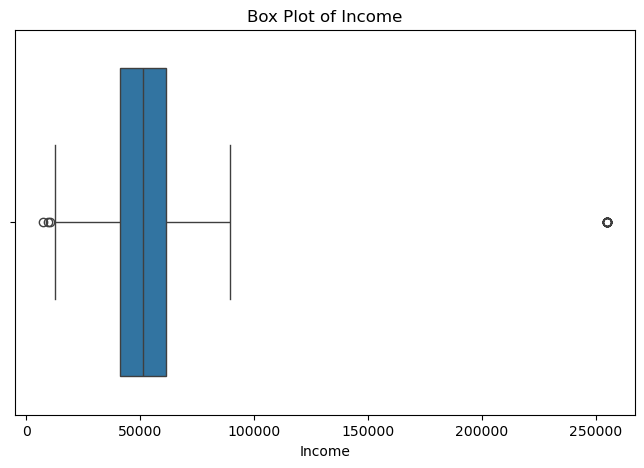

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["income"])
plt.title("Box Plot of Income")
plt.xlabel("Income")
plt.show()

In [18]:
median_income=round(median_income,7)
median_income

51298.8468121

In [20]:
#fill the income column missing values with median income
df['income'].fillna(median_income,inplace=True)
df['income'].isna()

C:\Users\Arunv\AppData\Local\Temp\ipykernel_15308\991782812.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(median_income,inplace=True)


0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: income, Length: 1000, dtype: bool